In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
from pmdarima import auto_arima, ARIMA, model_selection

In [3]:
df = pd.read_csv('../ARIMA,SARIMA,SARIMAX/daily_revenue.csv',index_col = 'date', parse_dates = True, dayfirst = True)
df.head()

,revenue,discount_rate,coupon_rate
date,,,
2018-01-01,"6,270,839",34.27%,1.09%
2018-01-02,"8,922,076",30.87%,1.08%
2018-01-03,"8,446,101",28.11%,1.01%
2018-01-04,"7,785,798",27.32%,0.96%
2018-01-05,"6,375,303",25.70%,0.90%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   revenue        1795 non-null   object
 1   discount_rate  1795 non-null   object
 2   coupon_rate    1795 non-null   object
dtypes: object(3)
memory usage: 56.1+ KB


In [5]:
# Transform revenue into a float
df['revenue'] = df['revenue'].str.replace(',', '').astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   revenue        1795 non-null   float64
 1   discount_rate  1795 non-null   object 
 2   coupon_rate    1795 non-null   object 
dtypes: float64(1), object(2)
memory usage: 56.1+ KB


In [6]:
# Setting the frequence
df = df.asfreq('D')

In [8]:
# change the time series vairable name
df.rename(columns = {'revenue':'y'}, inplace = True)
df.head()

,y,discount_rate,coupon_rate
date,,,
2018-01-01,6270839.0,34.27%,1.09%
2018-01-02,8922076.0,30.87%,1.08%
2018-01-03,8446101.0,28.11%,1.01%
2018-01-04,7785798.0,27.32%,0.96%
2018-01-05,6375303.0,25.70%,0.90%


# EDA

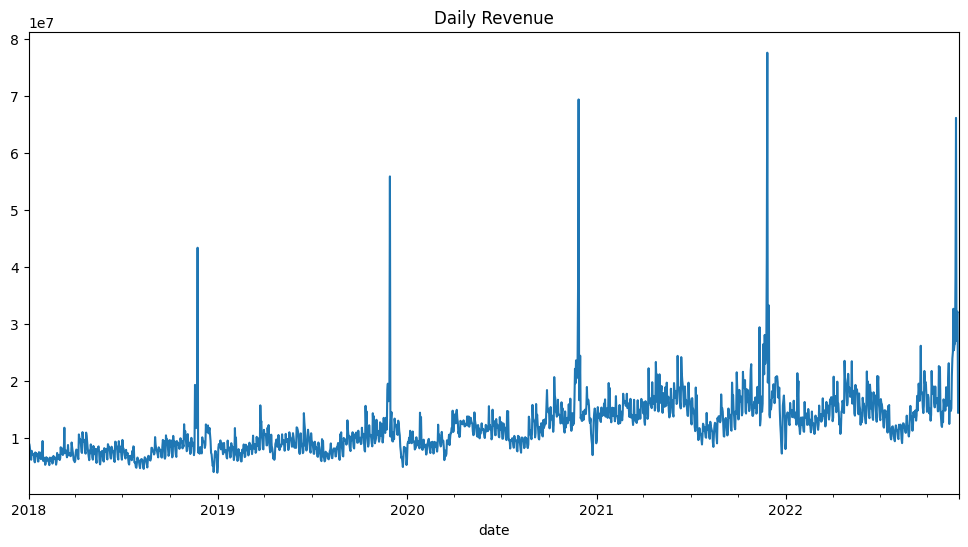

In [10]:
# Daily revenue plot
df['y'].plot(figsize = (12,6))
plt.title('Daily Revenue')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_28108\3885018770.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['y'].resample('M').mean(), ylabel='Revenue')


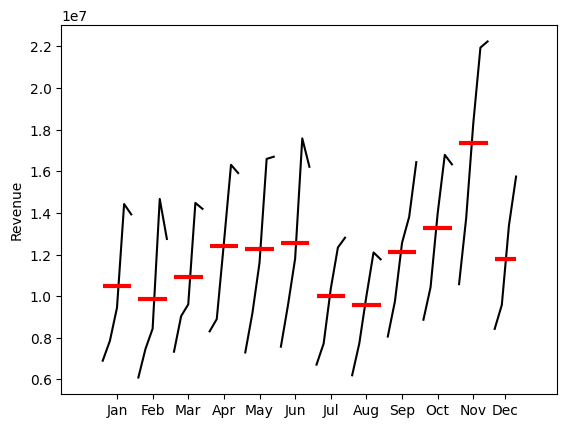

In [14]:
# Plot the monthly seasonality
month_plot(df['y'].resample('M').mean(), ylabel='Revenue')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_28108\3349294975.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['y'].resample('Q').mean(), ylabel='Revenue')


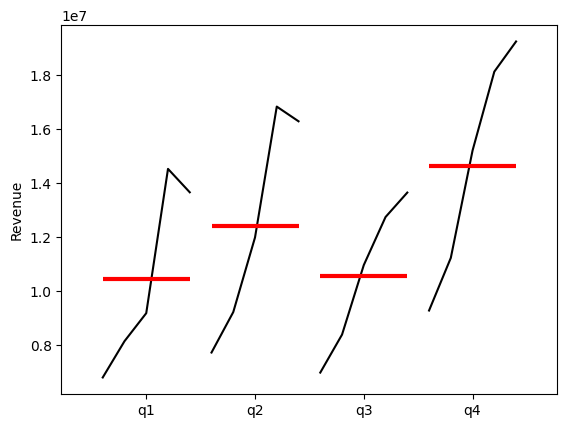

In [15]:
# plotting the quarterly seasonality
quarter_plot(df['y'].resample('Q').mean(), ylabel='Revenue')
plt.show()

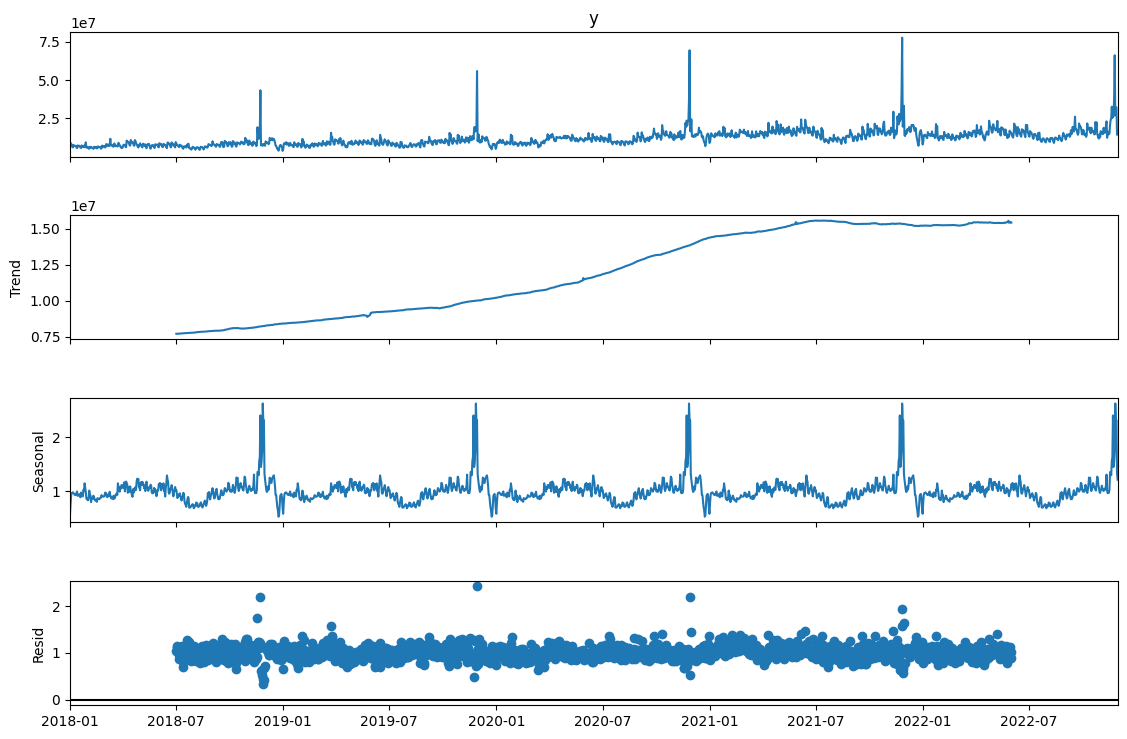

In [17]:
# seasonal decomposition
decomposition = seasonal_decompose(df['y'], model = 'multiplicative', period = 365)
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

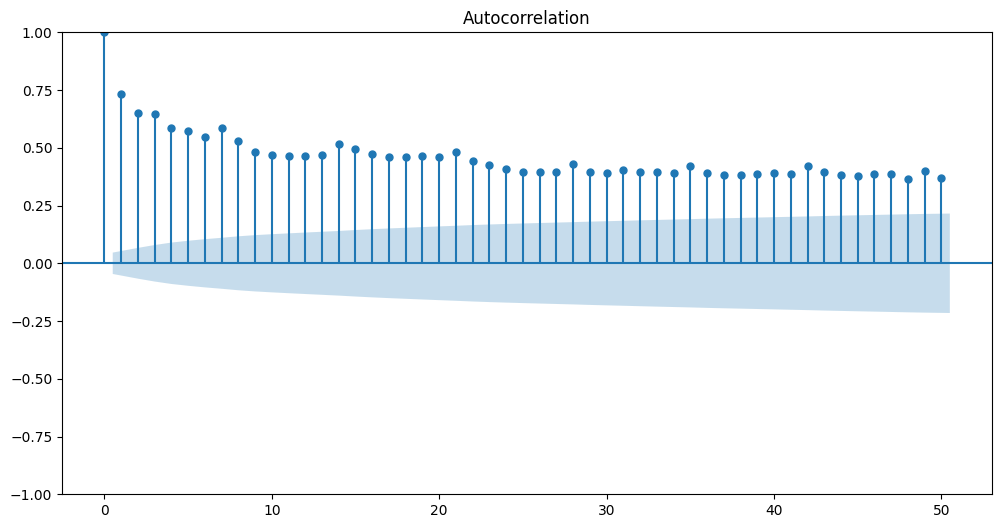

In [18]:
# Plot the auto correlation
fig, ax = plt.subplots(figsize = (12,6))
plot_acf(df['y'], lags = 50, ax = ax)
plt.show()

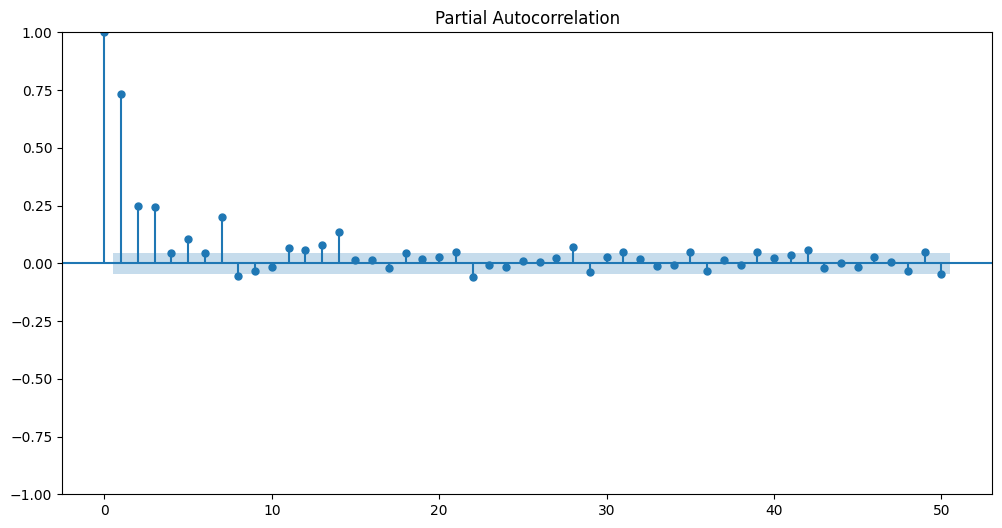

In [19]:
# Plot the partial auto correlation
fig, ax = plt.subplots(figsize = (12,6))
plot_pacf(df['y'], lags = 50, ax = ax)
plt.show()

# Stationarity

In [20]:
# Perform ADF test
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['y'])

print('p-value: %f' % result[1])

# Interpreting the ADF test results
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

p-value: 0.101904
The time series is non-stationary.


In [22]:
# Difference the time series
df['y_diff'] = df.y.diff().dropna()
df['y_diff']

date
2018-01-01           NaN
2018-01-02     2651237.0
2018-01-03     -475975.0
2018-01-04     -660303.0
2018-01-05    -1410495.0
                 ...    
2022-11-26   -39180777.0
2022-11-27     4955921.0
2022-11-28      210050.0
2022-11-29   -17786305.0
2022-11-30      712049.0
Freq: D, Name: y_diff, Length: 1795, dtype: float64

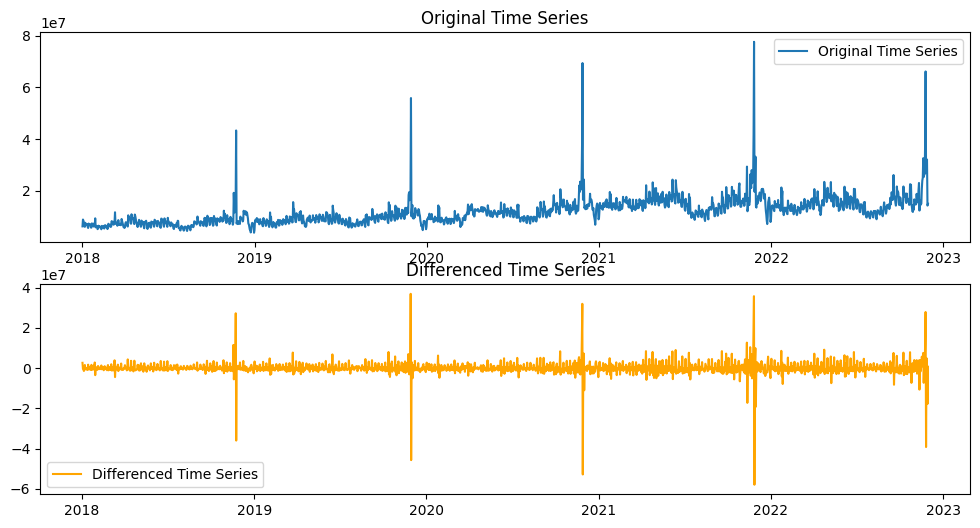

In [23]:
# Plotting the original and differenced time series
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df.y, label='Original Time Series')
plt.title('Original Time Series')
plt.legend()

plt.subplot(2,1,2)
plt.plot(df.y_diff, label='Differenced Time Series', color='orange')
plt.title('Differenced Time Series')
plt.legend()

In [24]:
result = adfuller(df['y_diff'].dropna())

print('p-value: %f' % result[1])

# Interpreting the ADF test results
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

p-value: 0.000000
The time series is stationary.


# ARIMA Model

In [28]:
# Split the data into train and test sets

test_days = 30
train = df[:-test_days]
test = df[-test_days:]
test.tail()

,y,discount_rate,coupon_rate,y_diff
date,,,,
2022-11-26,26934947.0,30.41%,0.38%,-39180777.0
2022-11-27,31890868.0,29.75%,0.35%,4955921.0
2022-11-28,32100918.0,25.27%,8.93%,210050.0
2022-11-29,14314613.0,19.54%,0.26%,-17786305.0
2022-11-30,15026662.0,17.10%,0.32%,712049.0


In [29]:
# using pmdarima for the arima model and the best parameters
model = auto_arima(train['y'], seasonal = False)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1765
Model:               SARIMAX(5, 1, 2)   Log Likelihood              -28817.267
Date:                Fri, 06 Mar 2026   AIC                          57650.535
Time:                        16:19:20   BIC                          57694.337
Sample:                    01-01-2018   HQIC                         57666.720
                         - 10-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4136      0.120     -3.449      0.001      -0.649      -0.179
ar.L2          0.3017      0.053      5.671      0.000       0.197       0.406
ar.L3          0.1570      0.028      5.705      0.000       0.103       0.211
ar.L4          0.0679      0.029      2.365      0.018       0.012       0.124
ar.L5          0.0466      0.024      1.937      0.053      -0.001       0.094
ma.L1         -0.1598      0.118     -1.354      0.176      -0.391       0.071
ma.L2         -0.7423      0.108     -6.872      0.000      -0.954      -0.531
sigma2      9.084e+12   1.86e-14   4.88e+26      0.000    9.08e+12    9.08e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            580903.26
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               3.04   Skew:                             5.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        91.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.23e+42. Standard errors may be unstable.
"""

In [30]:
# Predictions
predictions_arima = model.predict(n_periods = len(test))
predictions_arima

2022-11-01    1.445299e+07
2022-11-02    1.474103e+07
2022-11-03    1.503283e+07
2022-11-04    1.527520e+07
2022-11-05    1.534078e+07
2022-11-06    1.553442e+07
2022-11-07    1.554542e+07
2022-11-08    1.563967e+07
2022-11-09    1.565016e+07
2022-11-10    1.569221e+07
2022-11-11    1.570256e+07
2022-11-12    1.571953e+07
2022-11-13    1.572734e+07
2022-11-14    1.573420e+07
2022-11-15    1.573904e+07
2022-11-16    1.574197e+07
2022-11-17    1.574462e+07
2022-11-18    1.574600e+07
2022-11-19    1.574734e+07
2022-11-20    1.574804e+07
2022-11-21    1.574869e+07
2022-11-22    1.574906e+07
2022-11-23    1.574937e+07
2022-11-24    1.574956e+07
2022-11-25    1.574971e+07
2022-11-26    1.574981e+07
2022-11-27    1.574988e+07
2022-11-28    1.574994e+07
2022-11-29    1.574997e+07
2022-11-30    1.575000e+07
Freq: D, dtype: float64

In [36]:
# Function to assess model and visualize output
def model_assessment(train, test, predictions, chart_title):
  # Plot training, test, and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()
  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  mse = mean_squared_error(test, predictions)
  rmse = np.sqrt(mse)
  mape = mean_absolute_percentage_error(test, predictions)

  # print the metrics value
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")


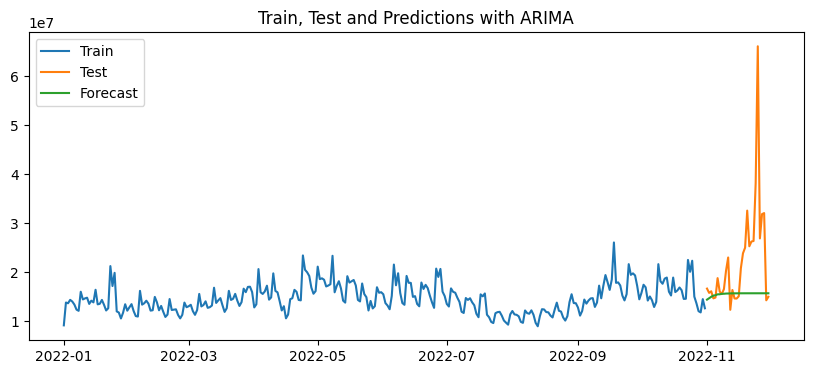

The MAE is 7267306.02
The RMSE is 12366038.30
The MAPE is 24.15 %


In [37]:
# Model assesment
model_assessment(train['y']['2022':], test['y'], predictions_arima, "ARIMA")